In [1]:
# ==============================================================================
# BLOCO 1: IMPORTAÇÕES E FUNÇÕES VISUAIS
# ==============================================================================
!pip install "numpy<2.0.0" scikit-learn-extra
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage

import re
from collections import Counter
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore")
warnings.filterwarnings('ignore', category=DeprecationWarning)
sns.set_theme(style="whitegrid")

In [2]:
# @title
def show_report(df, labels, cols_num, algo='kmeans'):
    df_relatorio = df.copy()
    df_relatorio['Cluster'] = list(labels)
    perfil = df_relatorio.groupby('Cluster')[cols_num].mean()
    perfil['quantidade_jogos'] = df_relatorio.groupby('Cluster').size()

    algo_lower = algo.lower()
    if algo_lower in ['kmeans', 'k-means', 'k_means']:
        algo_title = "K-MEANS"
    elif algo_lower in ['kmedoids', 'k-medoids', 'k_medoids']:
        algo_title = "K-MEDOIDS"
    else:
        algo_title = "AGRUPAMENTO HIERÁRQUICO"

    print("\n" + "="*102)
    print(f"{f'ANÁLISE PERFILADA DOS CLUSTERS ENCONTRADOS VIA {algo_title}':^102}")
    print("="*102)
    print(f"{'Cluster':^8} | {'Qtd Jogos':^10} | {'Média Peak CCU':^16} | {'% Positivos':^13} | {'Média Reviews':^14} | {'Média Donos':^14} | {'Média Preço':^13}")
    print("-" * 102)

    for cluster_id in sorted(df_relatorio['Cluster'].unique()):
        row = perfil.loc[cluster_id]
        qtd = int(row['quantidade_jogos'])
        ccu = f"{row['peak_ccu']:.1f}"
        pct_val = row['pct_pos_total']
        pct_pos = f"{pct_val*100:.1f}%" if pct_val <= 1 else f"{pct_val:.1f}%"
        reviews = f"{int(row['num_reviews_total'])}"
        owners = f"{int(row['estimated_owners'])}"
        price = f"$ {row['price']:.2f}"
        print(f"{cluster_id:^8} | {qtd:^10} | {ccu:^16} | {pct_pos:^13} | {reviews:^14} | {owners:^14} | {price:^13}")
    print("="*102)

def show_k_plots(K, elbow_scores, silhouette_scores, best_k_elbow, best_k_silhouette, algo='kmeans'):
    is_kmeans = algo.lower() in ['kmeans', 'k-means', 'k_means']
    algo_title = "K-Means" if is_kmeans else "K-Medoids"
    elbow_label = "Inércia (WCSS)" if is_kmeans else "Custo (Inércia)"
    ylabel_elbow = "Inércia / WCSS" if is_kmeans else "Dissimilaridade / Custo"
    color_elbow = '#1f77b4' if is_kmeans else '#ff7f0e'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(K, elbow_scores, marker='o', linestyle='-', color=color_elbow, linewidth=2)
    ax1.axvline(x=best_k_elbow, color='red', linestyle='--', label=f'Cotovelo Ideal (K={best_k_elbow})')
    ax1.set_title(f'{algo_title}: Método do Cotovelo', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
    ax1.set_ylabel(ylabel_elbow, fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)

    ax2.plot(K, silhouette_scores, marker='s', linestyle='-', color='#2ca02c', linewidth=2)
    ax2.axvline(x=best_k_silhouette, color='red', linestyle='--', label=f'Silhueta Ideal (K={best_k_silhouette})')
    ax2.set_title(f'{algo_title}: Coeficiente de Silhueta Médio', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
    ax2.set_ylabel('Score de Silhueta', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print(f"➜ Sugestão matemática pelo COTOVELO: K = {best_k_elbow}")
    print(f"➜ Sugestão matemática pela SILHUETA: K = {best_k_silhouette}")
    print("=" * 60)

def plot_scatter_clusters(X_grouping, cluster_labels, algo='kmeans'):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_grouping)

    df_plot = pd.DataFrame(X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
    df_plot['Cluster'] = list(cluster_labels)

    algo_lower = algo.lower()
    if algo_lower in ['kmeans', 'k-means', 'k_means']:
        algo_title, centroid_label = "K-Means", "Centróides (Médias)"
    elif algo_lower in ['kmedoids', 'k-medoids', 'k_medoids']:
        algo_title, centroid_label = "K-Medoids", "Medóides (Pontos Centrais)"
    else:
        algo_title, centroid_label = "Hierárquico", "Centroides do Grupo"

    plt.figure(figsize=(11, 7), dpi=100)
    sns.scatterplot(
        data=df_plot, x='Componente Principal 1', y='Componente Principal 2',
        hue='Cluster', palette='tab10', alpha=0.5, edgecolor='none', s=30
    )

    centroids_pca = df_plot.groupby('Cluster')[['Componente Principal 1', 'Componente Principal 2']].mean()
    plt.scatter(
        centroids_pca['Componente Principal 1'], centroids_pca['Componente Principal 2'],
        c="black", marker="X", s=250, edgecolors='white', linewidth=1.5, label=centroid_label, zorder=5
    )

    plt.title(f'Dispersão dos Clusters no Espaço Vetorial — {algo_title} (Redução PCA 2D)', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Volume de Mercado e Popularidade (PC1)', fontsize=12, fontweight='500')
    plt.ylabel('Perfil Crítico e de Monetização (PC2)', fontsize=12, fontweight='500')
    plt.legend(title=f'Grupos ({algo_title})', loc='best', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

In [3]:
# Configuração de reprodutibilidade
SEED = 42
np.random.seed(SEED)

# 1. Carregamento
df = pd.read_csv('/content/games_march2025_cleaned.csv', encoding='utf8')
print(df.shape)

# 2. Limpeza inicial
threshold = len(df) / 2
df = df.dropna(axis=1, thresh=threshold)

# Colunas úteis
useful_cols = [
    "name", "release_date", "price", "linux", "metacritic_score", "recommendations",
    "supported_languages", "developers", "publishers", "categories", "genres",
    "positive", "negative", "estimated_owners", "average_playtime_forever",
    "average_playtime_2weeks", "peak_ccu", "tags", "pct_pos_total",
    "num_reviews_total", "pct_pos_recent", "num_reviews_recent"
]
df = df[useful_cols].copy()

# 3. Limpeza da coluna estimated_owners
def calc_avg_owners(text):
    if not isinstance(text, str): return 0
    text = text.replace(",", "").replace(" ", "")
    sep = "-" if "-" in text else ".."
    try:
        valores = [float(v) for v in text.split(sep)]
        return np.mean(valores)
    except:
        return 0

# Substituir pela média do range
df['estimated_owners'] = df['estimated_owners'].apply(calc_avg_owners)

# 4. Processamento e Filtros de Significância numérica
cols_num = ["peak_ccu", "pct_pos_total", "num_reviews_total", "estimated_owners", "price"]

# Converte e limpa
for col in cols_num:
    # Converte erros em 0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Filtro de mercado: garante dados relevantes
df_processed = df[
    (df['peak_ccu'] >= 1) &
    (df['num_reviews_total'] >= 30) &
    (df['estimated_owners'] >= 100)
].copy()

# 5. Transformação Matemática (Log apenas em X_grouping)
# para eliminar a extrema distância entre os valores
X_grouping = df_processed[cols_num].copy()
cols_to_log = ["peak_ccu", "num_reviews_total", "estimated_owners"]
X_grouping[cols_to_log] = np.log1p(X_grouping[cols_to_log])

# Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_grouping)
X_grouping = pd.DataFrame(X_scaled, columns=cols_num, index=df_processed.index)

# 6. Amostragem determinística
sample_size = min(10000, len(X_grouping))
indices = np.random.choice(X_grouping.index, size=sample_size, replace=False)

X_amostra = X_grouping.loc[indices]
df_amostra = df_processed.loc[indices].copy()

print(f"Processamento concluído. Jogos válidos: {df_processed.shape}")

(89618, 47)
Processamento concluído. Jogos válidos: (15550, 22)


In [4]:
df_processed.shape

(15550, 22)

1. Processando tuning do K-Means (Base Completa)...


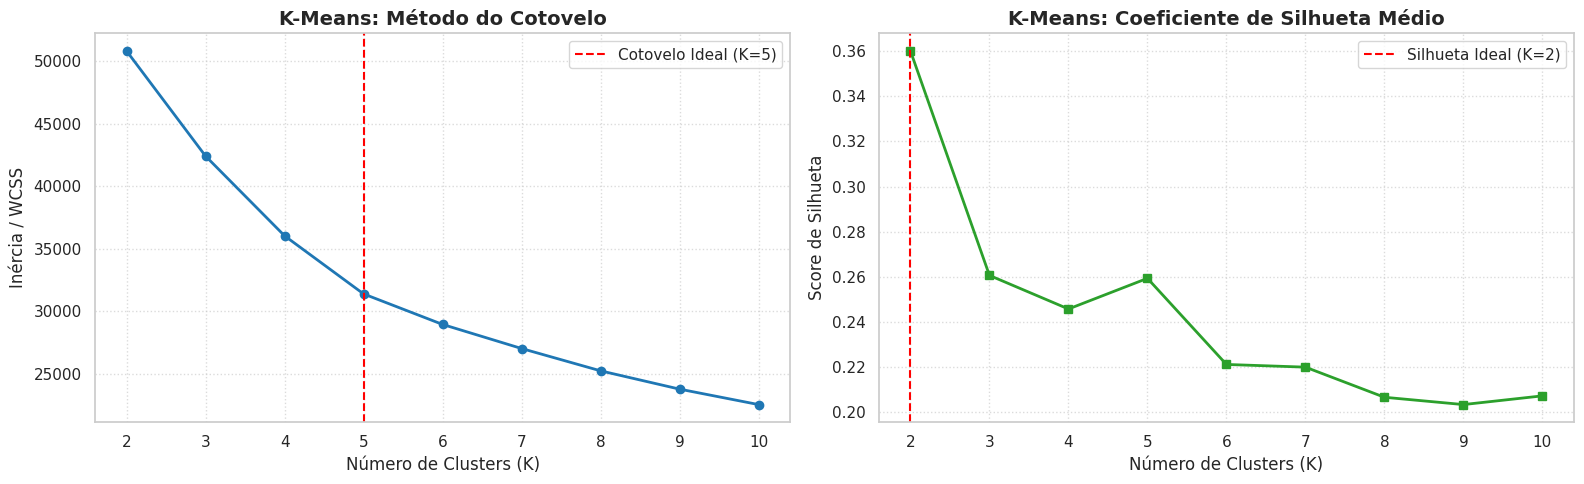

➜ Sugestão matemática pelo COTOVELO: K = 5
➜ Sugestão matemática pela SILHUETA: K = 2


In [5]:
# ==============================================================================
# BLOCO 3: K-MEANS
# ==============================================================================
print("1. Processando tuning do K-Means (Base Completa)...")
wcss_km = []
sil_km = []
K_range = list(range(2, 11))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_total = kmeans.fit_predict(X_grouping)
    wcss_km.append(kmeans.inertia_)

    # Cálculo da Silhueta no dataset completo (X_grouping)
    if k > 1: # Silhouette score exige pelo menos 2 clusters
        score = silhouette_score(X_grouping, labels_total, random_state=42)
        sil_km.append(score)
    else:
        sil_km.append(np.nan)

valid_scores = [s for s in sil_km if not np.isnan(s)]
best_k_sil_km = K_range[sil_km.index(max(valid_scores))]

# Matemática do Cotovelo
p1, p2 = np.array([K_range[0], wcss_km[0]]), np.array([K_range[-1], wcss_km[-1]])
distancias = [np.abs(np.cross(p2 - p1, p1 - np.array([K_range[i], wcss_km[i]]))) / np.linalg.norm(p2 - p1) for i in range(len(K_range))]
best_k_elbow_km = K_range[np.argmax(distancias)]

best_k_km = max(best_k_elbow_km, best_k_sil_km)

# Gráficos de Tuning
show_k_plots(K_range, wcss_km, sil_km, best_k_elbow_km, best_k_sil_km, algo='kmeans')

In [6]:
print(f"\n2. Treinando K-Means Definitivo com K={best_k_km}...")
km_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
df_processed['Cluster_KMeans'] = km_final.fit_predict(X_grouping)


2. Treinando K-Means Definitivo com K=5...


3. Gerando Gráfico de Dispersão PCA...


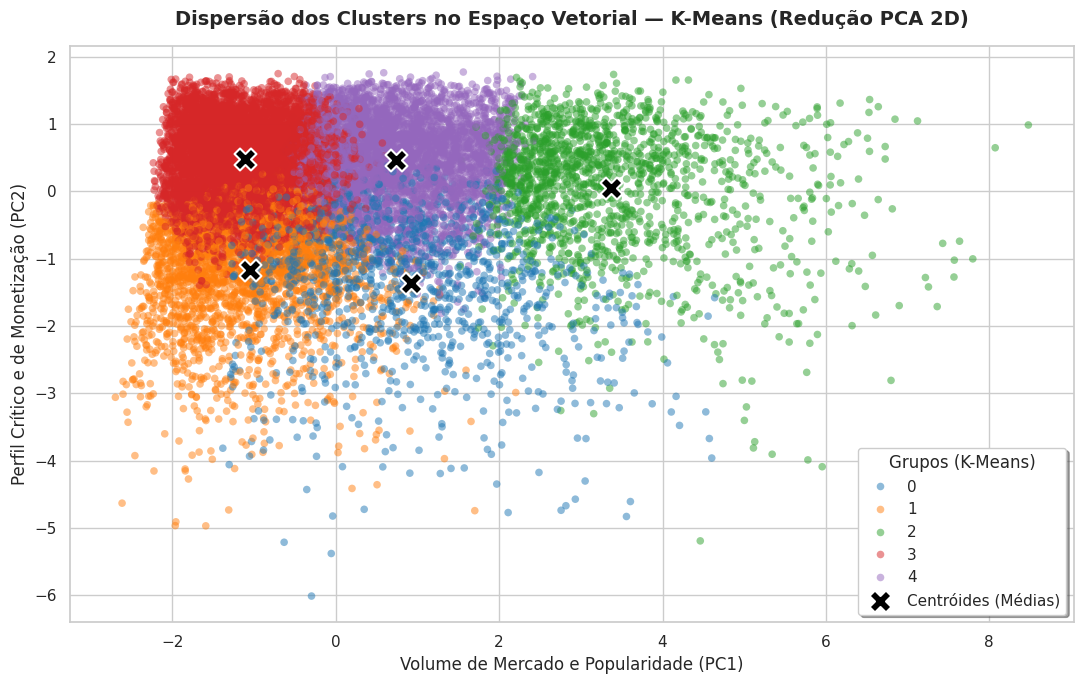

4. Relatório Final...

                        ANÁLISE PERFILADA DOS CLUSTERS ENCONTRADOS VIA K-MEANS                        
Cluster  | Qtd Jogos  |  Média Peak CCU  |  % Positivos  | Média Reviews  |  Média Donos   |  Média Preço 
------------------------------------------------------------------------------------------------------
   0     |    1184    |      168.2       |     78.2%     |      2251      |     159265     |    $ 39.70   
   1     |    2757    |       9.2        |     60.9%     |      443       |     87771      |    $ 9.62    
   2     |    1584    |      5128.7      |     86.0%     |     58291      |    3505956     |    $ 19.96   
   3     |    5923    |       7.4        |     87.0%     |      245       |     24023      |    $ 9.93    
   4     |    4102    |       34.3       |     85.7%     |      2591      |     337205     |    $ 9.97    


In [7]:
print("3. Gerando Gráfico de Dispersão PCA...")
plot_scatter_clusters(X_grouping, df_processed['Cluster_KMeans'], algo='kmeans')

print("4. Relatório Final...")
show_report(df_processed, df_processed['Cluster_KMeans'], cols_num, algo='kmeans')

In [8]:
# 1. Atribua os labels do cluster de volta ao dataframe de origem
# Supondo que seu modelo se chame 'kmeans'
df_processed['cluster_id'] = kmeans.labels_

# 2. Função para extrair os jogos de um cluster específico
def get_jogos_por_cluster(cluster_id, top_n=10):
    # Filtra o dataframe pelo ID do cluster
    df_cluster = df_processed[df_processed['cluster_id'] == cluster_id].copy()

    # Ordena pelos jogos mais relevantes (ex: maior número de donos ou nota)
    df_cluster = df_cluster.sort_values(by='estimated_owners', ascending=False)

    return df_cluster[['name', 'price', 'pct_pos_total', 'estimated_owners', 'peak_ccu']]

# 3. Exemplo de uso: Extrair jogos do Cluster 2
jogos_cluster_2 = get_jogos_por_cluster(cluster_id=2)
jogos_cluster_3 = get_jogos_por_cluster(cluster_id=3)

# Mostrar os primeiros da lista
print(f"Jogos do Cluster 2:")
print(jogos_cluster_2.head(10))
print(f"Jogos do Cluster 3:")
print(jogos_cluster_3.head(10))

Jogos do Cluster 2:
                                         name  price  pct_pos_total  \
10                         Black Myth: Wukong  59.99             96   
60                        New World: Aeternum  59.99             68   
14                             Cyberpunk 2077  59.99             85   
16                            Baldur's Gate 3  59.99             96   
12                                 ELDEN RING  59.99             92   
80               Mount & Blade II: Bannerlord  49.99             87   
69                            Hogwarts Legacy  59.99             90   
67  Sekiro™: Shadows Die Twice - GOTY Edition  59.99             95   
66                          Battlefield™ 2042  59.99             48   
58               Sid Meier’s Civilization® VI  59.99             86   

    estimated_owners  peak_ccu  
10        75000000.0     35990  
60        75000000.0     10420  
14        35000000.0     29239  
16        35000000.0     48021  
12        35000000.0     46121  


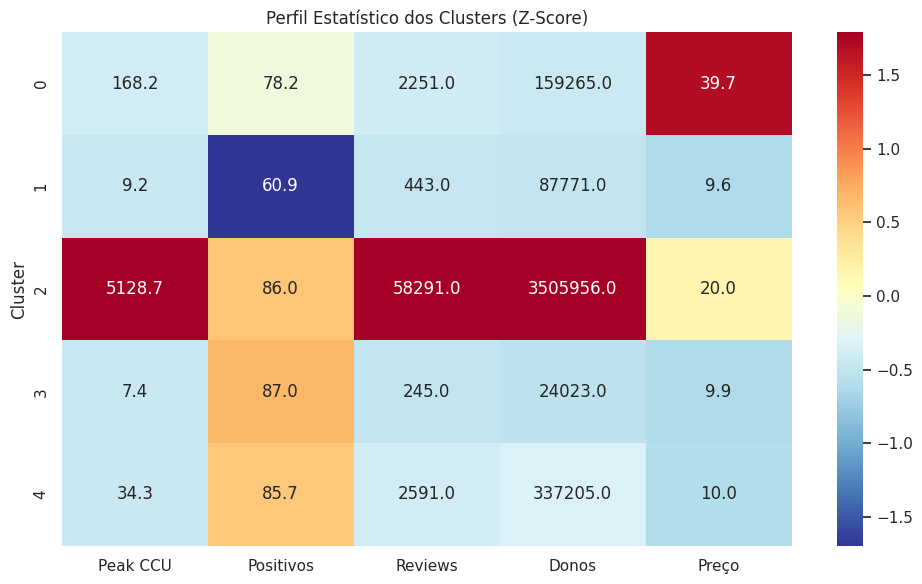

In [9]:
# Seus dados
data = {
    'Cluster': [0, 1, 2, 3, 4],
    'Peak CCU': [168.2, 9.2, 5128.7, 7.4, 34.3],
    'Positivos': [78.2, 60.9, 86.0, 87.0, 85.7],
    'Reviews': [2251, 443, 58291, 245, 2591],
    'Donos': [159265, 87771, 3505956, 24023, 337205],
    'Preço': [39.70, 9.62, 19.96, 9.93, 9.97]
}
df_plot = pd.DataFrame(data).set_index('Cluster')

# Opcional: normalizar os dados para as cores fazerem mais sentido no heatmap
df_norm = (df_plot - df_plot.mean()) / df_plot.std()

plt.figure(figsize=(10, 6))
sns.heatmap(df_norm, annot=df_plot.values, fmt=".1f", cmap="RdYlBu_r", cbar=True)
plt.title("Perfil Estatístico dos Clusters (Z-Score)")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=300)

1. Processando tuning do K-Medoids (Amostragem O(n²))...


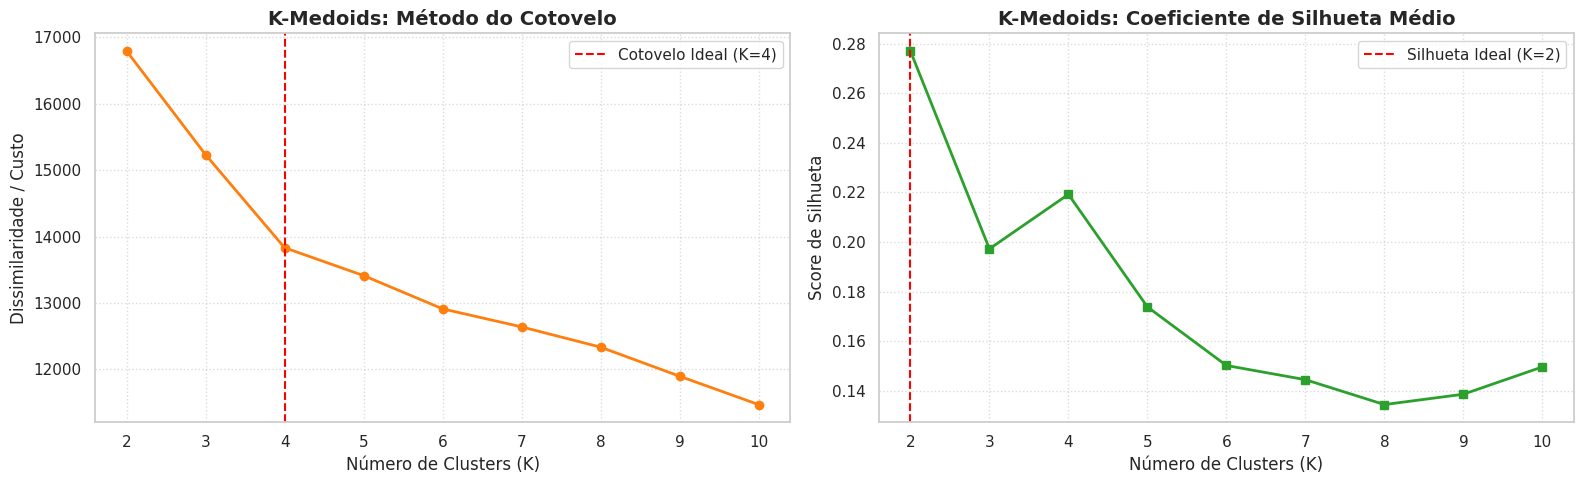

➜ Sugestão matemática pelo COTOVELO: K = 4
➜ Sugestão matemática pela SILHUETA: K = 2


In [10]:
# ==============================================================================
# BLOCO 4: K-MEDOIDS
# ==============================================================================
print("1. Processando tuning do K-Medoids (Amostragem O(n²))...")
kmedoids_costs = []
kmedoids_silhouettes = []

for k in K_range:
    kmedoids_model = KMedoids(n_clusters=k, random_state=42, method='alternate')
    labels_amostra_medoids = kmedoids_model.fit_predict(X_amostra)
    kmedoids_costs.append(kmedoids_model.inertia_)

    if len(np.unique(labels_amostra_medoids)) > 1:
        kmedoids_silhouettes.append(silhouette_score(X_amostra, labels_amostra_medoids, random_state=42))
    else:
        kmedoids_silhouettes.append(np.nan)

valid_sil_medoids = [s for s in kmedoids_silhouettes if not np.isnan(s)]
best_k_sil_kmed = K_range[kmedoids_silhouettes.index(max(valid_sil_medoids))]

p1_med, p2_med = np.array([K_range[0], kmedoids_costs[0]]), np.array([K_range[-1], kmedoids_costs[-1]])
dist_medoids = [np.abs(np.cross(p2_med - p1_med, p1_med - np.array([K_range[i], kmedoids_costs[i]]))) / np.linalg.norm(p2_med - p1_med) for i in range(len(K_range))]
best_k_elbow_kmed = K_range[np.argmax(dist_medoids)]

# Gráficos de Tuning
show_k_plots(K_range, kmedoids_costs, kmedoids_silhouettes, best_k_elbow_kmed, best_k_sil_kmed, algo='kmedoids')

In [11]:
print(f"\n2. Treinando K-Medoids Definitivo com K={best_k_elbow_kmed} (Treina na Amostra, Prevê no Total)...")
kmed_final = KMedoids(n_clusters=best_k_elbow_kmed, random_state=42, method='alternate')
kmed_final.fit(X_amostra)
df_processed['Cluster_KMedoids'] = kmed_final.predict(X_grouping)


2. Treinando K-Medoids Definitivo com K=4 (Treina na Amostra, Prevê no Total)...


3. Gerando Gráfico de Dispersão PCA...


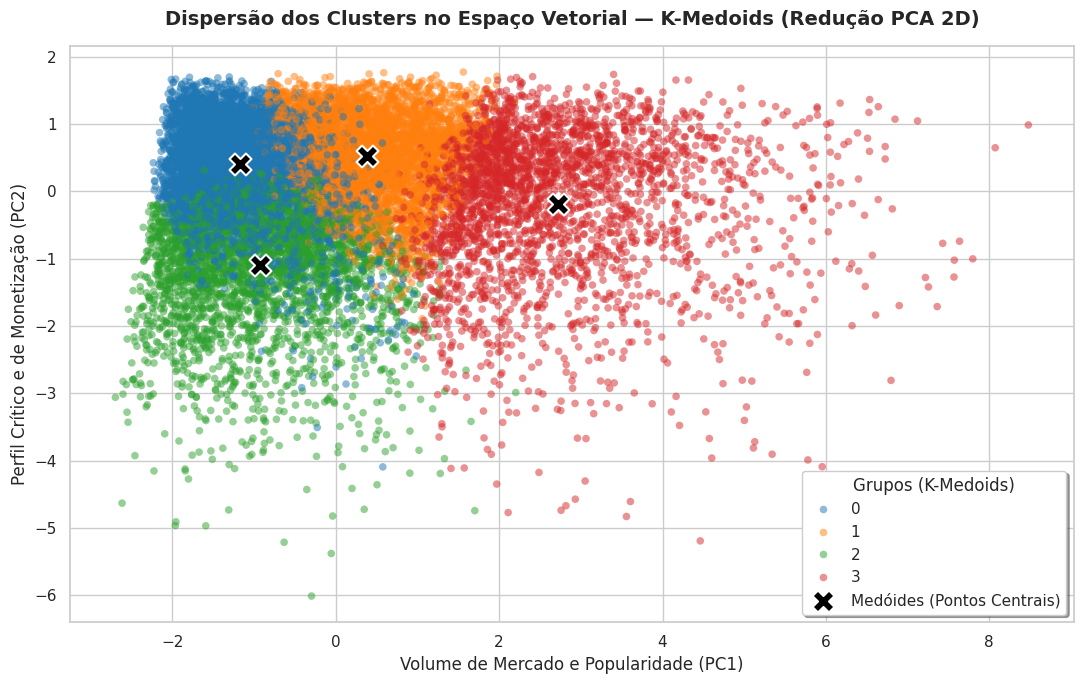

4. Relatório Final...

                       ANÁLISE PERFILADA DOS CLUSTERS ENCONTRADOS VIA K-MEDOIDS                       
Cluster  | Qtd Jogos  |  Média Peak CCU  |  % Positivos  | Média Reviews  |  Média Donos   |  Média Preço 
------------------------------------------------------------------------------------------------------
   0     |    4999    |       9.0        |     87.3%     |      200       |     16419      |    $ 11.89   
   1     |    4303    |       15.1       |     87.0%     |      1815      |     239881     |    $ 10.25   
   2     |    3503    |       10.0       |     63.2%     |      480       |     87653      |    $ 11.19   
   3     |    2745    |      3055.7      |     84.3%     |     35631      |    2217907     |    $ 22.63   


In [12]:
print("3. Gerando Gráfico de Dispersão PCA...")
plot_scatter_clusters(X_grouping, df_processed['Cluster_KMedoids'], algo='kmedoids')

print("4. Relatório Final...")
show_report(df_processed, df_processed['Cluster_KMedoids'], cols_num, algo='kmedoids')

In [13]:
# ==============================================================================
# BLOCO 5: AGRUPAMENTO HIERÁRQUICO
# ==============================================================================
print("1. Processando tuning da Silhueta para Agrupamento Hierárquico (Amostragem)...")
linked_hc = linkage(X_amostra, method='ward')
sil_hc = []

for k in K_range:
    hc_temp = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_temp = hc_temp.fit_predict(X_amostra)
    if len(np.unique(labels_temp)) > 1:
        sil_hc.append(silhouette_score(X_amostra, labels_temp, random_state=42))
    else:
        sil_hc.append(np.nan)

valid_sil_hc = [s for s in sil_hc if not np.isnan(s)]
best_k_hc = K_range[sil_hc.index(max(valid_sil_hc))]

print(f"➜ Avaliação de Silhueta concluída. Melhor K escolhido: {best_k_hc}")

1. Processando tuning da Silhueta para Agrupamento Hierárquico (Amostragem)...
➜ Avaliação de Silhueta concluída. Melhor K escolhido: 2


In [ ]:
# O Dendrograma assume a função visual do "Cotovelo" para o modelo Hierárquico
print("\n2. Gerando Dendrograma...")
cut_height_hc = sorted(linked_hc[:, 2], reverse=True)[best_k_hc - 1]
plt.figure(figsize=(14, 6), dpi=100)
dendrogram(linked_hc, truncate_mode="lastp", p=400, leaf_rotation=90, leaf_font_size=9, show_contracted=True, color_threshold=cut_height_hc)
plt.axhline(y=cut_height_hc, c='red', linestyle='--', label=f"Corte para {best_k_hc} Clusters")
plt.title("Dendrograma do Agrupamento Hierárquico (Ward)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Subgrupos e Nós Colapsados")
plt.ylabel("Distância Euclidiana")
plt.legend(shadow=True)
plt.grid(True, linestyle=':', alpha=0.4, axis='y')
plt.show()


2. Gerando Dendrograma...


In [ ]:
print(f"\n3. Treinando Agrupamento Hierárquico Definitivo com K={best_k_hc}...")
hc_final = AgglomerativeClustering(n_clusters=best_k_hc, linkage='ward')
labels_hc_final = hc_final.fit_predict(X_amostra)

# Passando os labels gerados apenas para a base de amostragem!
df_amostra['Cluster_Hierarchical'] = labels_hc_final

In [ ]:
print("4. Gerando Gráfico de Dispersão PCA...")
plot_scatter_clusters(X_amostra, df_amostra['Cluster_Hierarchical'], algo='hierarchical')

print("5. Relatório Final...")
# Note que aqui passamos df_amostra para bater exatamente com as predições!
show_report(df_amostra, df_amostra['Cluster_Hierarchical'], cols_num, algo='hierarchical')

In [ ]:
# ==============================================================================
# Regras de associação
# ==============================================================================
print("1. Calculando limites estatísticos e tratando a base...")
df_mercado = df_processed.copy()

# Limpeza preventiva contra formatações corrompidas
df_mercado['tags'] = df_mercado['tags'].astype(str).str.replace('{', '', regex=False)
df_mercado['genres'] = df_mercado['genres'].astype(str).str.replace('{', '', regex=False)

# Cálculo de quantis de sucesso
limite_preco = df_mercado['price'].quantile(0.75)
limite_rec = df_mercado['pct_pos_total'].quantile(0.75)
jogos_com_playtime = df_mercado[df_mercado['average_playtime_forever'] > 0]
limite_playtime = jogos_com_playtime['average_playtime_forever'].quantile(0.75)
limite_ccu = df_mercado['peak_ccu'].quantile(0.95)

tags_ruido = {
    'indie', 'singleplayer', 'multiplayer', '2d', '3d', 'action', 'adventure', 'casual', 'd',
    'free to play', 'free-to-play', 'freetoplay', 'early access', '[]', '', 'none', 'violent', 'gore', 'rogue-lite',
    'D Platformer'
}

print("2. Higienizando tags...")
tags_combinadas = df_mercado['tags'].astype(str) + "," + df_mercado['genres'].astype(str)

def limpar_string_tags(series_texto):
    passo1 = series_texto.str.replace(r"[\[\]'\"']", "", regex=True)
    passo2 = passo1.str.replace(r':\s*\d+|\d+', '', regex=True)
    return passo2

tags_limpas_series = limpar_string_tags(tags_combinadas)

# Foco no Top 60 para eliminar ruídos e acelerar o processo
todas_tags = [t.strip() for lista in tags_limpas_series.str.split(',') for t in lista if t.strip() and t.strip().lower() not in tags_ruido]
top_60_tags = set([tag for tag, _ in Counter(todas_tags).most_common(60)])

In [ ]:
print("3. Estruturando cestos de transações...")
cestos = []
precos = df_mercado['price'].to_numpy()
recomendacoes = df_mercado['pct_pos_total'].to_numpy()
playtimes = df_mercado['average_playtime_forever'].to_numpy()
ccus = df_mercado['peak_ccu'].to_numpy()
listas_tags = tags_limpas_series.str.split(',').to_numpy()

for i in range(len(df_mercado)):
    cesto = [t.strip() for t in listas_tags[i] if t.strip() and t.strip() in top_60_tags]

    if precos[i] >= limite_preco: cesto.append("$_PREMIUM")
    elif precos[i] == 0: cesto.append("$_FREE-TO-PLAY")
    if recomendacoes[i] >= limite_rec: cesto.append("⭐_ACLAMADO")
    if playtimes[i] >= limite_playtime: cesto.append("⏱️_ALTA_RETENÇÃO")
    if ccus[i] >= limite_ccu: cesto.append("🔥_HIT_VIRAL")

    cestos.append(list(set(cesto)))

print("4. Executando codificação binária...")
te = TransactionEncoder()
te_ary = te.fit(cestos).transform(cestos)
df_regras = pd.DataFrame(te_ary, columns=te.columns_)

min_sup = 1 / 100
min_conf = 20 / 100

print("5. Minerando itens frequentes via Apriori...")
freq_items = apriori(df_regras, min_support=min_sup, use_colnames=True, max_len=3)

print("6. Gerando regras de associação...")
# Enviamos o bloco completo (sem filtros prévios) para evitar o KeyError
regras = association_rules(freq_items, metric="confidence", min_threshold=min_conf)

In [ ]:
# ==============================================================================
# SCRIPT DE IMPRESSÃO INDIVIDUALIZADA
# ==============================================================================
def imprimir_relatorio(df_rules, titulo, condicao_ant, condicao_cons):
    if df_rules.empty: return
    df_f = df_rules[df_rules['antecedents'].apply(condicao_ant) & df_rules['consequents'].apply(condicao_cons)].copy()

    print("\n" + "="*110)
    print(f" PESQUISA DE MERCADO: {titulo}")
    print("="*110)
    if df_f.empty:
        print(" [Aviso] Sem padrões estatisticamente expressivos para esta relação.")
        print("="*110)
        return
    # df_f = df_f.sort_values(by=['lift', 'confidence'], ascending=[False, False]).head(8)
    df_f = df_f.sort_values(by=['lift', 'confidence'], ascending=[False, False]).head(10)
    print(f"{'Antecedente':<45} | {'Consequente':<35} | {'Suporte':<7} | {'Conf.':<6} | {'Lift':<5}")
    print("-" * 110)
    for _, row in df_f.iterrows():
        ant = ", ".join(list(row['antecedents']))
        con = list(row['consequents'])[0]
        print(f"{ant:<45} | {con:<35} | {row['support']*100:>5.1f}% | {row['confidence']*100:>4.1f}% | {row['lift']:.2f}")
    print("="*110)

SELOS = ('$_', '⭐_', '⏱️_', '🔥_')
def apenas_tags_puras(itens): return not any(i.startswith(SELOS) for i in itens)
def alvo_unico(itens, prefixo): return len(itens) == 1 and list(itens)[0].startswith(prefixo)

imprimir_relatorio(regras, "1. SINERGIA DE GAMEDEV (Mecânicas interdependentes)", apenas_tags_puras, lambda c: apenas_tags_puras(c) and len(c) == 1)
imprimir_relatorio(regras, "2. PODER DE PRECIFICAÇÃO (O que justifica cobrar valores Premium?)", apenas_tags_puras, lambda c: alvo_unico(c, "$_PREMIUM"))
imprimir_relatorio(regras, "3. ECOSSISTEMA GRATUITO (Nichos que performam melhor sob modelo F2P)", apenas_tags_puras, lambda c: alvo_unico(c, "$_FREE-TO-PLAY"))
imprimir_relatorio(regras, "4. RECEITA DA ACLAMAÇÃO (Design que maximiza a satisfação do usuário)", apenas_tags_puras, lambda c: alvo_unico(c, "⭐_ACLAMADO"))
imprimir_relatorio(regras, "5. MOTORES DE ENGAJAMENTO (Mecânicas que maximizam o tempo de jogo)", apenas_tags_puras, lambda c: alvo_unico(c, "⏱️_ALTA_RETENÇÃO"))
imprimir_relatorio(regras, "6. POTENCIAL VIRAL (Quais nichos estouram o pico de jogadores simultâneos?)", apenas_tags_puras, lambda c: alvo_unico(c, "🔥_HIT_VIRAL"))

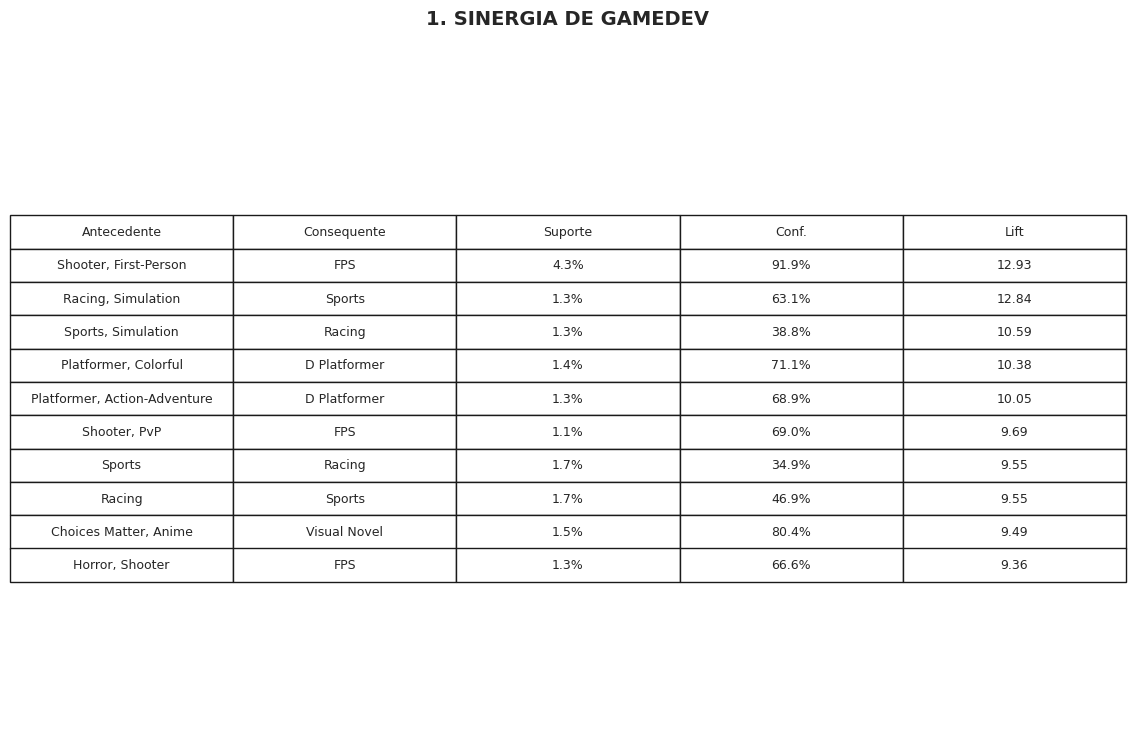

Relatório '1. SINERGIA DE GAMEDEV' processado.


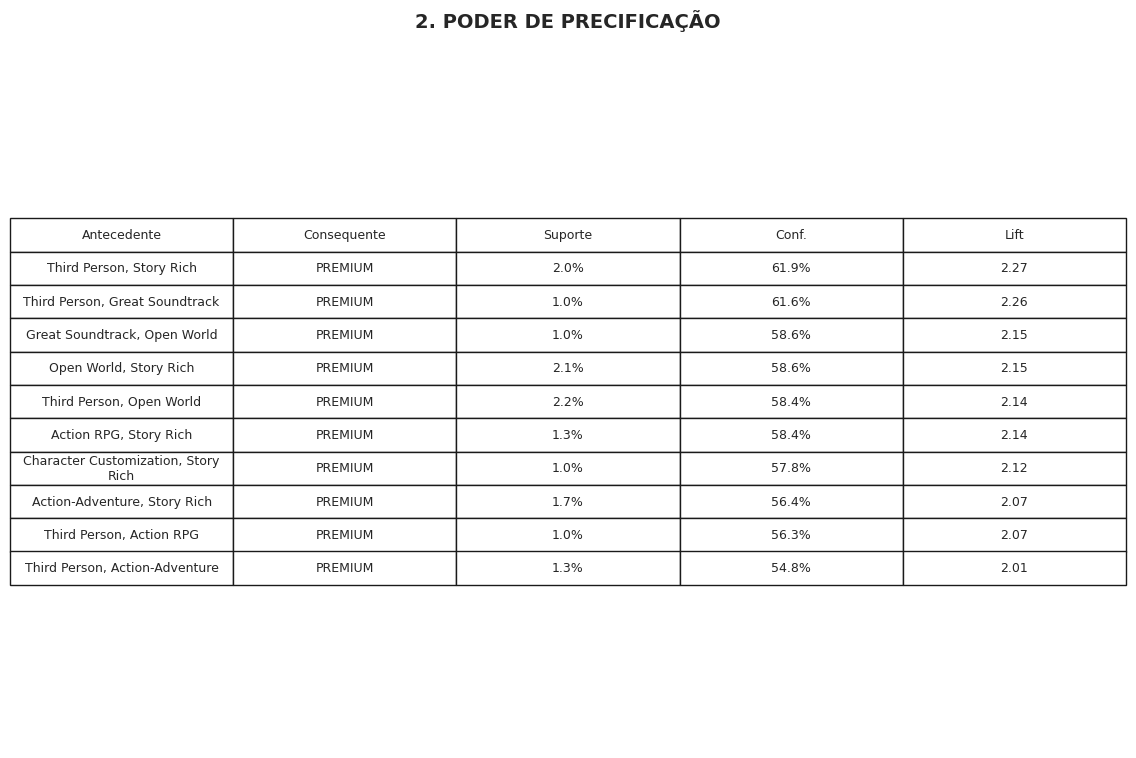

Relatório '2. PODER DE PRECIFICAÇÃO' processado.


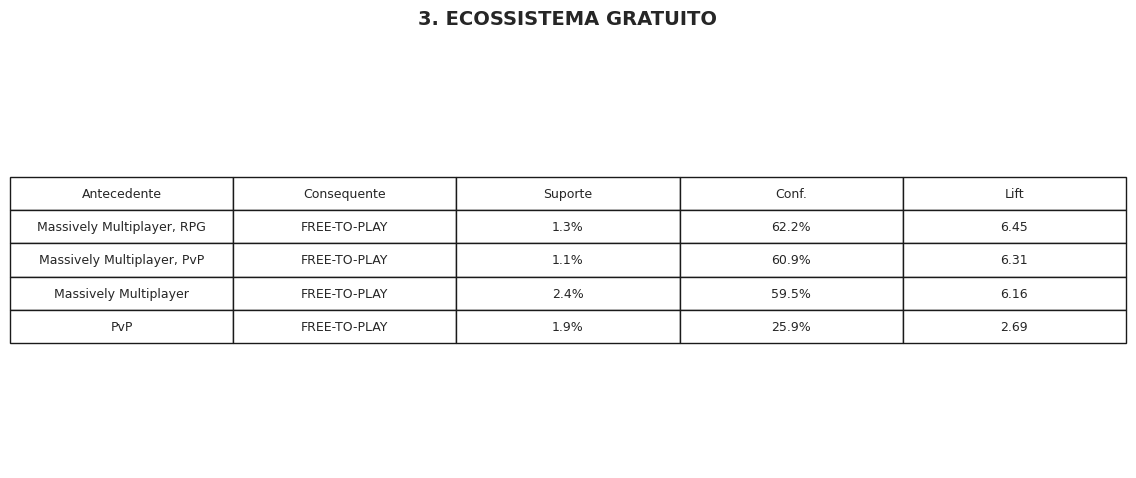

Relatório '3. ECOSSISTEMA GRATUITO' processado.


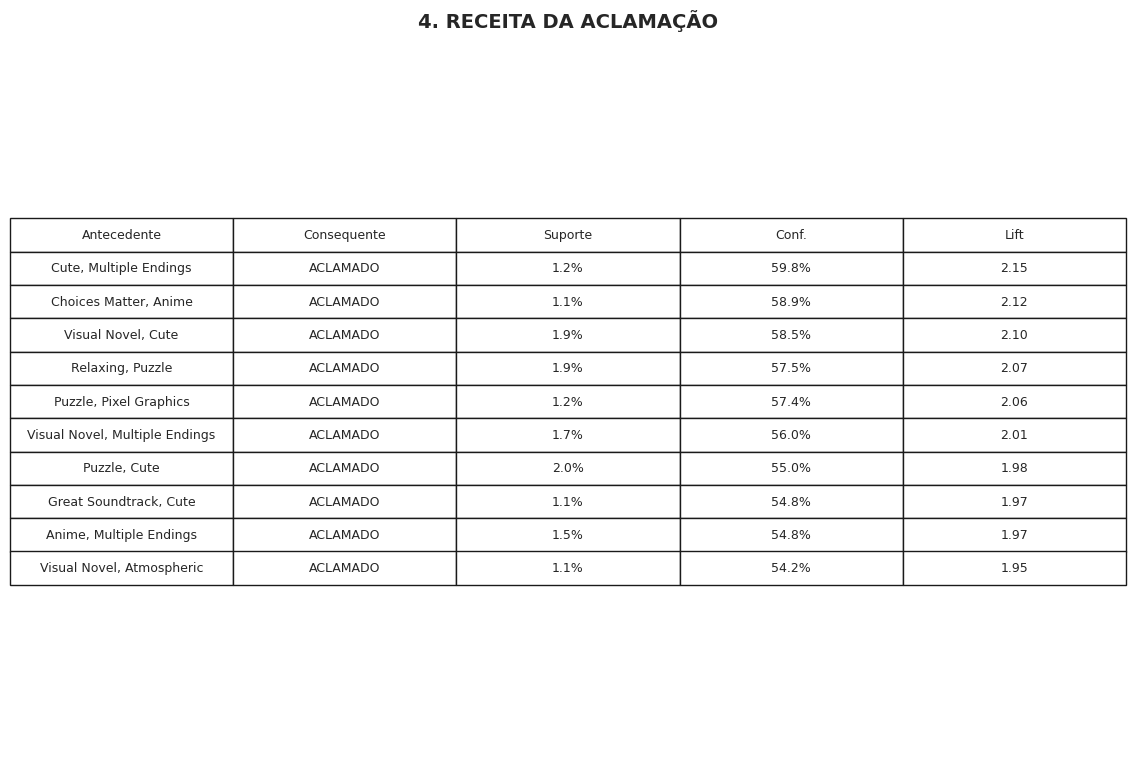

Relatório '4. RECEITA DA ACLAMAÇÃO' processado.


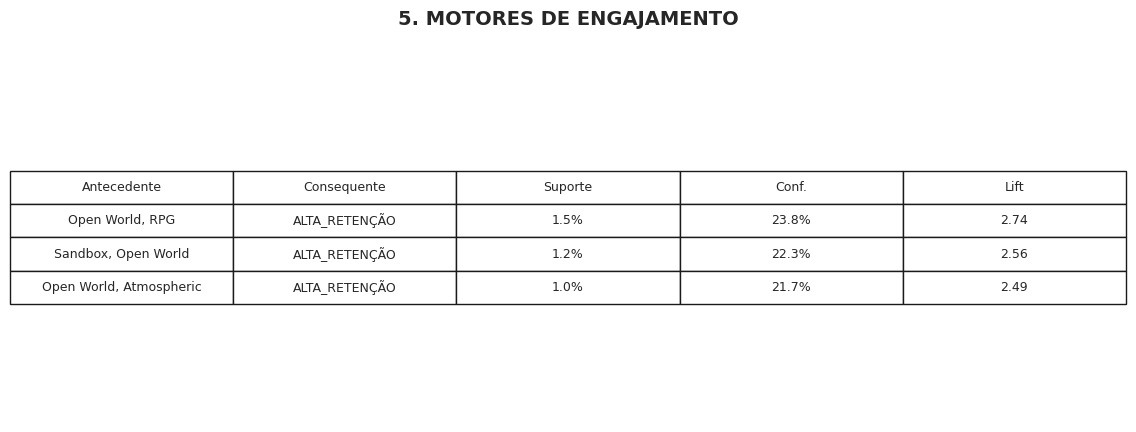

Relatório '5. MOTORES DE ENGAJAMENTO' processado.


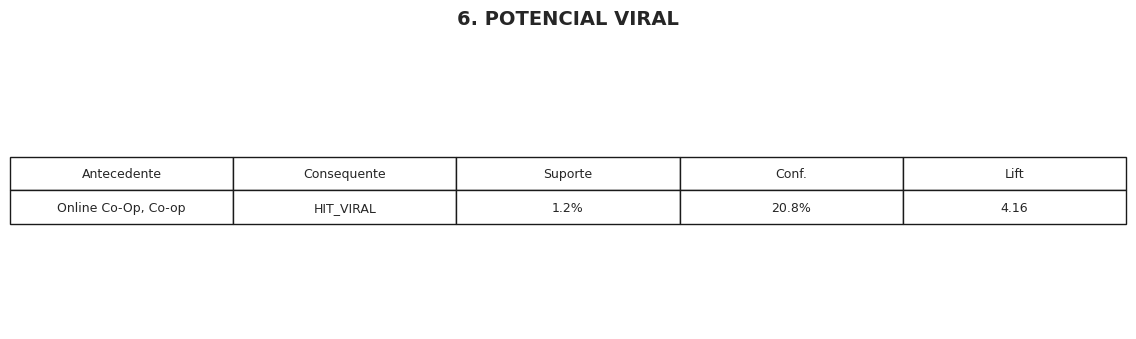

Relatório '6. POTENCIAL VIRAL' processado.


In [21]:
import textwrap

# Função para limpar o nome da tag (remove emoji e o primeiro underscore)
def limpar_nome(nome):
    return nome.split('_', 1)[-1] if '_' in nome else nome

# Atualização da função para remover emojis na filtragem e exibição
def alvo_unico_sem_emoji(itens, nome_alvo):
    lista_itens = list(itens)
    if len(lista_itens) != 1:
        return False
    return limpar_nome(lista_itens[0]) == nome_alvo

def gerar_tabela_imagem(df_rules, titulo, condicao_ant, condicao_cons, nome_arquivo):
    df_f = df_rules[df_rules['antecedents'].apply(condicao_ant) &
                    df_rules['consequents'].apply(condicao_cons)].copy()

    if df_f.empty: return

    df_f = df_f.sort_values(by=['lift', 'confidence'], ascending=[False, False]).head(10)
    num_linhas = len(df_f) # Pegamos o número real de linhas

    dados_tabela = []
    wrapper = textwrap.TextWrapper(width=30)

    for _, row in df_f.iterrows():
        ant_texto = ", ".join(list(row['antecedents']))
        ant_wrap = "\n".join(wrapper.wrap(ant_texto))
        con_limpo = limpar_nome(list(row['consequents'])[0])
        dados_tabela.append([ant_wrap, con_limpo, f"{row['support']*100:.1f}%", f"{row['confidence']*100:.1f}%", f"{row['lift']:.2f}"])

    # Dinamismo: A altura (segundo número) ajusta-se ao número de linhas (2.0 + 0.5 por linha)
    altura_dinamica = 3 + (num_linhas * 0.6)
    fig, ax = plt.subplots(figsize=(12, altura_dinamica))

    ax.set_title(f"{titulo}", fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    colunas = ['Antecedente', 'Consequente', 'Suporte', 'Conf.', 'Lift']
    tabela = ax.table(cellText=dados_tabela, colLabels=colunas, loc='center', cellLoc='center')

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)

    # Ajuste fino da escala para ficar compacto
    tabela.scale(1.2, 2.0)


    plt.show()

# Configurações limpas (sem emojis)
configuracoes = [
    ("1. SINERGIA DE GAMEDEV", apenas_tags_puras, lambda c: apenas_tags_puras(c) and len(c) == 1, "sinergia_gamedev"),
    ("2. PODER DE PRECIFICAÇÃO", apenas_tags_puras, lambda c: alvo_unico_sem_emoji(c, "PREMIUM"), "poder_precificacao"),
    ("3. ECOSSISTEMA GRATUITO", apenas_tags_puras, lambda c: alvo_unico_sem_emoji(c, "FREE-TO-PLAY"), "ecossistema_f2p"),
    ("4. RECEITA DA ACLAMAÇÃO", apenas_tags_puras, lambda c: alvo_unico_sem_emoji(c, "ACLAMADO"), "receita_aclamacao"),
    ("5. MOTORES DE ENGAJAMENTO", apenas_tags_puras, lambda c: alvo_unico_sem_emoji(c, "ALTA_RETENÇÃO"), "motores_engajamento"),
    ("6. POTENCIAL VIRAL", apenas_tags_puras, lambda c: alvo_unico_sem_emoji(c, "HIT_VIRAL"), "potencial_viral")
]

# Execução
for titulo, cond_ant, cond_cons, nome_arq in configuracoes:
    gerar_tabela_imagem(regras, titulo, cond_ant, cond_cons, nome_arq)
    print(f"Relatório '{titulo}' processado.")